In [1]:
import boto3
import botocore
from IPython.core.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmfxdz0
interpreter: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
notebook name: 2025-11-25-external-selfbb-timeshift
notebook path: /home/runner/work/oee4/oee4/binder/2025-11-25-external-selfbb-timeshift.ipynb
revision: bdac574
timestamp: 2025-11-25T16:00:27Z00:00

IPython==7.16.1
packaging==25.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-11-25-external-timeshift"


In [5]:
df_all = []
for what, prefix in [
    ("nobb", "endeavor=16/external-competitions/stage=2+what=collated/"),
    ("selfbb", "endeavor=16/external-competitions-focalbb/stage=2+what=collated/"),
    ("selfbb33", "endeavor=16/external-competitions-bg33-focalbb/stage=2+what=collated/"),
    ("selfbb40", "endeavor=16/external-competitions-bg40-focalbb/stage=2+what=collated/"),
    ("selfbb50", "endeavor=16/external-competitions-bg50-focalbb/stage=2+what=collated/"),
    ("selfbb66", "endeavor=16/external-competitions-bg66-focalbb/stage=2+what=collated/"),
    ("selfbb75", "endeavor=16/external-competitions-bg75-focalbb/stage=2+what=collated/"),
    ("truebb", "endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/"),
    ("selfbb90", "endeavor=16/external-competitions-bg90-focalbb/stage=2+what=collated/"),
    ("selfbb99", "endeavor=16/external-competitions-bg99-focalbb/stage=2+what=collated/"),
]:
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket("prq49")


    competitions = bucket_handle.objects.filter(Prefix=prefix)
    dfs = [
        pd.read_csv(
          f's3://prq49/{competitions.key}',
        )
        for competitions in competitions
    ]
    print(len(dfs))
    df = pd.concat(dfs, ignore_index=True)
    df["kind"] = what

    df_all.append(df)

df = pd.concat(df_all, ignore_index=True)


100
100
20
20
20
20
20
99
20
20


0         1.000000
2         0.247078
4         0.006954
6         0.393959
8         0.299972
            ...   
169217    0.000000
169220    0.000000
169223    0.929577
169225    0.147200
169228    1.000000
Name: Focal Prevalence, Length: 61157, dtype: float64

0         1.0
2         0.0
4         0.0
6         0.0
8         0.0
         ... 
169217    0.0
169220    0.0
169223    1.0
169225    0.0
169228    1.0
Name: Focal Prevalence Rounded, Length: 61157, dtype: float64

teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


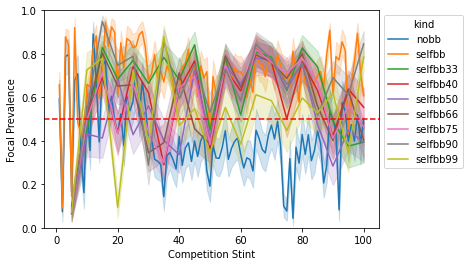

In [6]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
display(dfx["Focal Prevalence"])

dfx["Focal Prevalence Rounded"] = dfx["Focal Prevalence"].round()
display(dfx["Focal Prevalence Rounded"])


with tp.teed(
    sns.lineplot,
    data=dfx[
        dfx["kind"] != "truebb"
    ],
    x="Competition Stint",
    y="Focal Prevalence",
    hue="kind",
    teeplot_subdir=teeplot_subdir,
) as ax:
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    plt.axhline(y=0.5, color='r', linestyle='--')
    plt.ylim(0, 1)


0         1.000000
2         0.247078
4         0.006954
6         0.393959
8         0.299972
            ...   
169217    0.000000
169220    0.000000
169223    0.929577
169225    0.147200
169228    1.000000
Name: Focal Prevalence, Length: 61157, dtype: float64

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


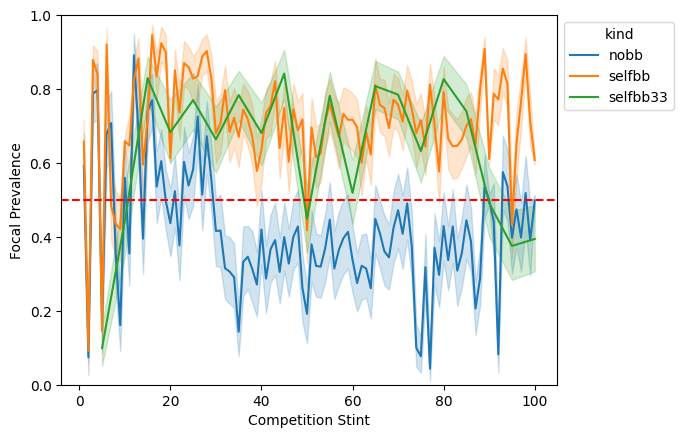

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


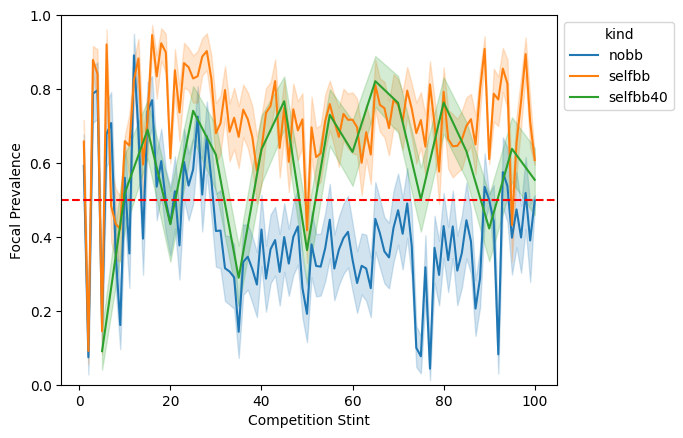

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


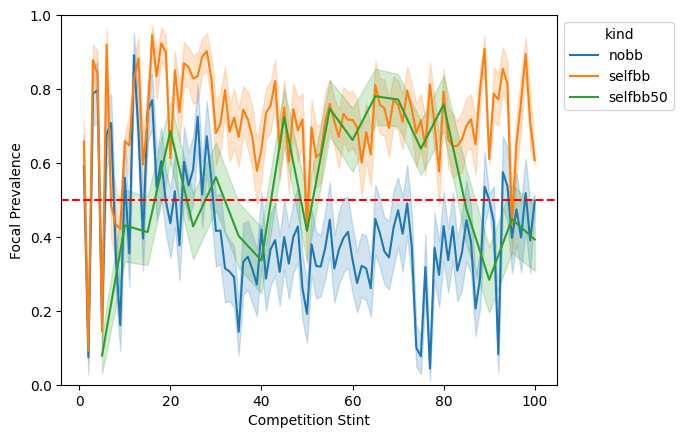

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


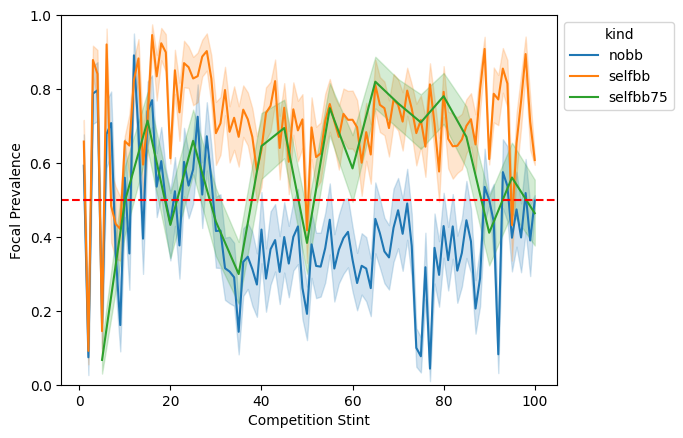

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


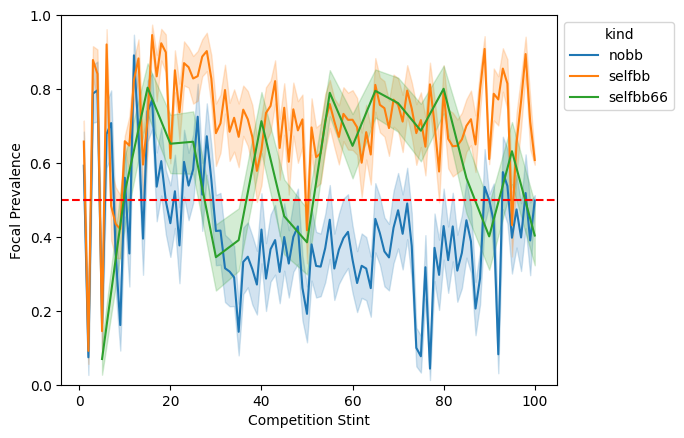

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


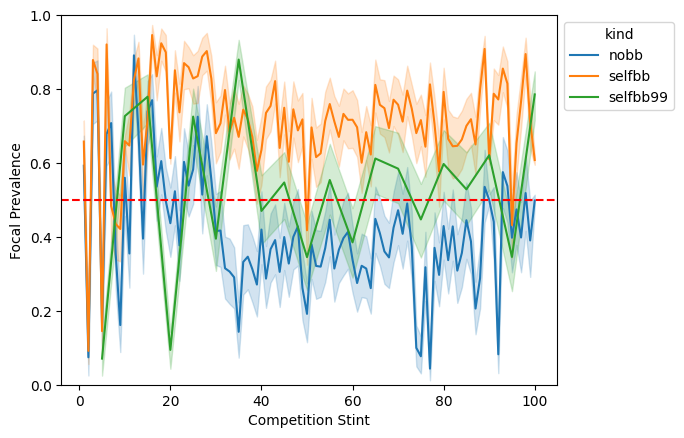

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


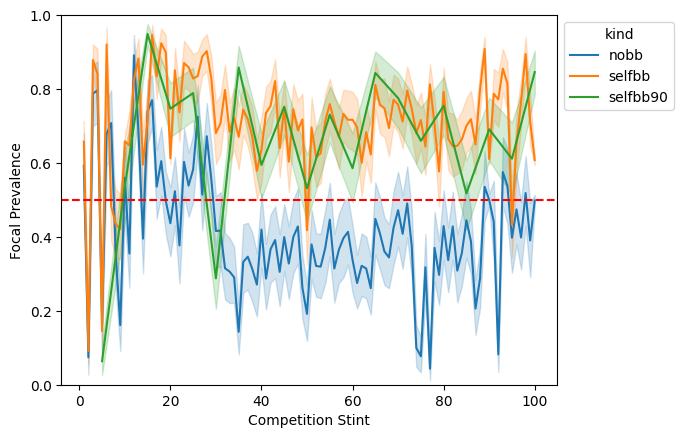

In [7]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
display(dfx["Focal Prevalence"])

for kind in [
    "selfbb33",
    "selfbb40",
    "selfbb50",
    "selfbb75",
    "selfbb66",
    "selfbb99",
    "selfbb90",
]:
    with tp.teed(
        sns.lineplot,
        data=dfx[
            dfx["kind"].isin(["nobb", kind, "selfbb"])
        ],
        x="Competition Stint",
        y="Focal Prevalence",
        hue="kind",
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

        plt.axhline(y=0.5, color='r', linestyle='--')
        plt.ylim(0, 1)
